# Custom Surface Site Analysis
## Identifies unique adsorption sites on any surface using graph isomorphism

Supports: flat slabs (fcc111, fcc332, …), stepped surfaces, surfaces with defects (vacancies), oxide overlayers, and any custom geometry via ACAT `CustomSurface`.

### Example slabs provided
| File | Surface type |
|---|---|
| `pd332.xyz` | Pd(332) stepped metal surface |
| `pt111_no_defect.xyz` | Pt(111) flat terrace |
| `pt111_defect_middle.xyz` | Pt(111) with a vacancy |
| `rutile_110.xyz` | TiO₂ rutile(110) oxide |
| `alpha_PtO2_layer.xyz` | α-PtO₂ oxide layer |
| `fe2o3.xyz` | Fe₂O₃ oxide surface |

In [ ]:
# User input
xyz_path = "/home/shikim/pynta-production/preprocessing-mace/oxide/alpha_PtO2_layer.xyz"
n_layers = 2
facet = None   
# facet: conventional ACAT surface string ("fcc111", "fcc332", "fcc211", ...)
#        Set to None to use CustomSurface (graph-isomorphism, for non-standard surfaces).

In [15]:
# Cell 1: imports (DO NOT EDIT)
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../../..')))
from ase import Atom, Atoms
import copy
from ase.io import read, write, Trajectory
from acat.settings import CustomSurface
from acat.adsorption_sites import SlabAdsorptionSites
from ase.build import surface, fcc111
from ase.visualize import view
import importlib
import site_analysis as sa
importlib.reload(sa)
import json

In [16]:
# visualize
slab = read(xyz_path)
view(slab, viewer='x3d')

In [17]:
# Suggest n_layers for CustomSurface
# Run this cell to check what n_layers should be set to in Cell 2.
slab = read(xyz_path)
sa.suggest_n_layers(slab)

Suggested n_layers = 4

   Layer  z mean (Å)  n atoms
  ──────────────────────────────
       1       0.059       27
       2       1.598       27
       3       3.138       27
       4       4.677       27


4

In [18]:
# workflow parameters
adsorbate_height = 1.0
site_bond_cutoff = 1.5
tag_symbol = "Ne"     # used only if defect is detected
dz = 0.1
stable_steps = 3
verbose = True

In [19]:
# Cell 3: run workflow
# workflow_auto detects defects automatically and picks the right path:
#   - no defect → workflow_no_defect_unique_sites (uses facet string or CustomSurface)
#   - defect    → workflow_defect_vacancy_drop    (always uses CustomSurface)
sa.workflow_auto(
    xyz_path=xyz_path,
    n_layers=n_layers,
    adsorbate_height=adsorbate_height,
    site_bond_cutoff=site_bond_cutoff,
    facet=facet,
    tag_symbol=tag_symbol,
    dz=dz,
    stable_steps=stable_steps,
    verbose=verbose,
)

Found 0 defect site(s)
Sites data saved to 'sites.json'.
Neighbor site list saved to 'neighbor_site_list.json'.
Sites data saved to 'labeled_sites.json'.
Surface             : CustomSurface
Total ACAT sites    : 108
Sites written       : 108
Distinct labels     : 8

  Label        Site type      Morphology
  --------------------------------------------
  sc-tc0       bridge         sc-tc
  sc-tc1       3fold          sc-tc
  sc-tc2       3fold          sc-tc
  sc-tc3       bridge         sc-tc
  step0        ontop          step
  step1        bridge         step
  terrace0     ontop          terrace
  terrace1     bridge         terrace

Wrote: unique_sites.traj
Wrote: sites.json
Wrote: neighbor_site_list.json
Wrote: labeled_sites.json


([Atoms(symbols='NeO72Pt36', pbc=[True, True, False], cell=[13.51006709, 13.51716258, 26.15683565], layer=...),
  Atoms(symbols='NeO72Pt36', pbc=[True, True, False], cell=[13.51006709, 13.51716258, 26.15683565], layer=...),
  Atoms(symbols='NeO72Pt36', pbc=[True, True, False], cell=[13.51006709, 13.51716258, 26.15683565], layer=...),
  Atoms(symbols='NeO72Pt36', pbc=[True, True, False], cell=[13.51006709, 13.51716258, 26.15683565], layer=...),
  Atoms(symbols='NeO72Pt36', pbc=[True, True, False], cell=[13.51006709, 13.51716258, 26.15683565], layer=...),
  Atoms(symbols='NeO72Pt36', pbc=[True, True, False], cell=[13.51006709, 13.51716258, 26.15683565], layer=...),
  Atoms(symbols='NeO72Pt36', pbc=[True, True, False], cell=[13.51006709, 13.51716258, 26.15683565], layer=...),
  Atoms(symbols='NeO72Pt36', pbc=[True, True, False], cell=[13.51006709, 13.51716258, 26.15683565], layer=...),
  Atoms(symbols='NeO72Pt36', pbc=[True, True, False], cell=[13.51006709, 13.51716258, 26.15683565], laye

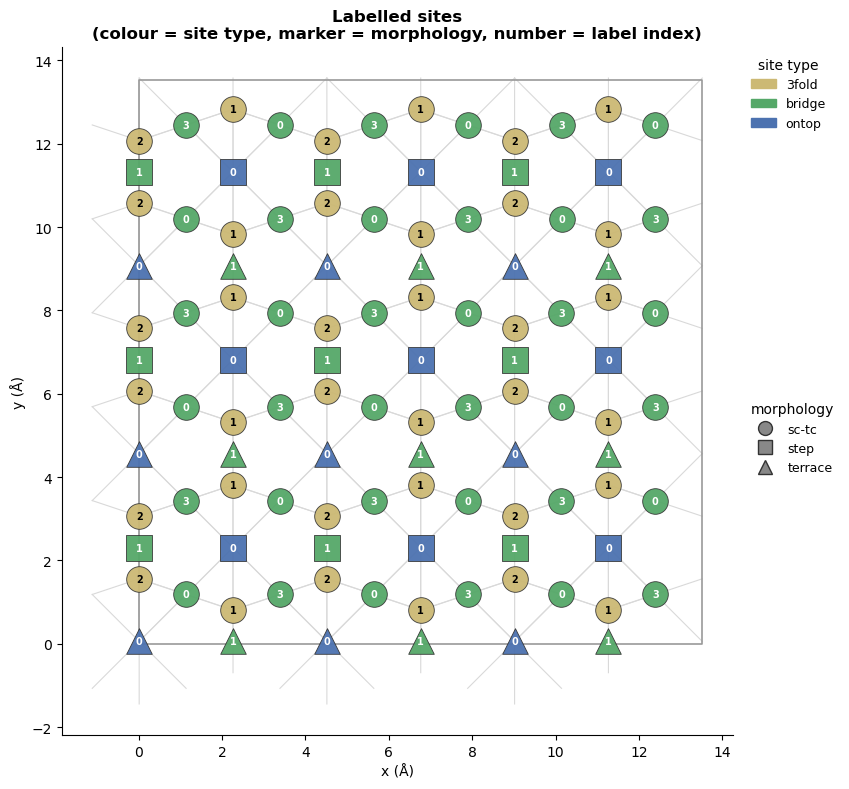

Saved: labeled_sites_xy.png


In [20]:
# Visualize the labeled sites in the xy plane
#   colour        = site type   (ontop / bridge / 3fold / ...)
#   marker shape  = morphology  (terrace / step / corner / sc-tc / ...)
#   number inside = label index (isomorphic sites share the same number)
sa.plot_labeled_sites_xy(
    labeled_sites_json="labeled_sites.json",
    xyz_path=xyz_path,
)

## Defect Site Analysis
Runs automatically if a vacancy is detected in the slab.
Produces `panel1_void_ring.traj`, `panel2_drop_steps.traj`, `panel3_void_sites.traj` and matching PNG figures.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from ase.neighborlist import NeighborList
from ase.geometry import get_distances

# additional parameters (not in Cell 2)
max_drop      = 25.0   # Å — must exceed void depth + 3 Å starting offset
min_clearance = 1.3    # Å — stop if probe gets this close to any slab atom
margin        = 0.25   # Å — added to d_NN to set CN cutoff radius
uniq_tol      = 0.25   # Å — deduplication tolerance for unique probe positions

# detect defect
slab  = read(xyz_path)
nslab = len(slab)

defect_sites = sa.workflow_detect_vacancies(slab, nslab, verbose=True)
has_defect   = len(defect_sites) > 0

if has_defect:
    void_pos = defect_sites[0]['position']
    print(f'\nDefect detected → running defect site analysis')
    print(f'Void centroid: x={void_pos[0]:.3f}  y={void_pos[1]:.3f}  z={void_pos[2]:.3f}')
else:
    void_pos = None
    print('\nNo defect detected — defect analysis cells will be skipped.')

Found 0 defect site(s)

No defect detected — defect analysis cells will be skipped.


In [22]:
# Panel 1 — void ring trajectory + top-view figure
if not has_defect:
    print('No defect — skipping Panel 1.')
else:
    top     = sa._top_surface_indices(slab, nslab)
    use_pbc = sa._has_reasonable_cell(slab)
    d_nn    = sa._estimate_nn_distance_xy(slab, top, use_pbc_xy=use_pbc)
    cutoff  = 1.25 * d_nn

    nl = NeighborList([cutoff] * nslab, self_interaction=False, bothways=True, skin=0.0)
    nl.update(slab)
    top_set = set(top.tolist())
    deg = np.zeros(len(top), dtype=int)
    for ii, a in enumerate(top):
        neigh, _ = nl.get_neighbors(a)
        deg[ii]  = sum(1 for j in neigh if j in top_set)

    expected   = int(np.median(deg))
    under_top  = top[deg <= (expected - 1)]
    print(f'Top-layer atoms  : {len(top)}')
    print(f'Expected degree  : {expected}')
    print(f'Undercoordinated : {len(under_top)}')

    frame0 = slab.copy()
    frame1 = slab.copy()
    for idx in under_top:
        pos     = slab.positions[idx].copy()
        pos[2] += 0.5
        frame1 += Atoms('He', positions=[pos])
    frame2  = frame1.copy()
    frame2 += Atoms(tag_symbol, positions=[void_pos])

    traj1 = Trajectory('panel1_void_ring.traj', 'w')
    for f in [frame0, frame1, frame2]:
        traj1.write(f)
    traj1.close()
    print('Wrote: panel1_void_ring.traj  (frame0=clean, frame1=ring He, frame2=+Ne centroid)')

    top_pos, under_pos = slab.positions[top], slab.positions[under_top]
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(top_pos[:, 0], top_pos[:, 1], c='steelblue', s=220,
               edgecolors='k', linewidths=0.6, zorder=2, label='surface atoms')
    ax.scatter(under_pos[:, 0], under_pos[:, 1], c='tomato', s=260,
               edgecolors='k', linewidths=1.2, zorder=3,
               label=f'undercoordinated (deg ≤ {expected-1})')
    ax.scatter(void_pos[0], void_pos[1], c='gold', s=350, marker='*',
               edgecolors='k', linewidths=0.9, zorder=4, label='void centroid')
    ax.set_xlabel('x (Å)', fontsize=12)
    ax.set_ylabel('y (Å)', fontsize=12)
    ax.set_title(f'Panel 1: Void ring — {xyz_path}', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.savefig('panel1_void_ring.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: panel1_void_ring.png')

No defect — skipping Panel 1.


In [23]:
# Panel 2 — noble-gas drop trajectory + CN vs z figure
if not has_defect:
    print('No defect — skipping Panel 2.')
else:
    NOBLE_GASES = {'He', 'Ne', 'Ar', 'Kr', 'Xe', 'Rn'}

    def _estimate_first_nn(atoms):
        idx = [i for i, a in enumerate(atoms) if a.symbol not in NOBLE_GASES]
        if len(idx) < 2:
            return 3.0
        pos = atoms.positions[idx]
        _, dmat = get_distances(pos, pos, cell=atoms.cell, pbc=atoms.pbc)
        dmat = np.array(dmat)
        np.fill_diagonal(dmat, np.inf)
        nn = np.min(dmat, axis=1)
        nn = nn[np.isfinite(nn)]
        return float(np.median(nn)) if len(nn) else 3.0

    def _tag_cn(atoms, i_tag, cutoff):
        # direct distance — avoids NeighborList's pair-cutoff doubling
        idx = [j for j, a in enumerate(atoms) if j != i_tag and a.symbol not in NOBLE_GASES]
        if not idx:
            return 0, []
        _, d = get_distances(atoms.positions[i_tag:i_tag+1], atoms.positions[idx],
                             cell=atoms.cell, pbc=atoms.pbc)
        d = np.array(d).ravel()
        neigh = [idx[k] for k in range(len(idx)) if d[k] < cutoff]
        return len(neigh), neigh

    def _min_dist_to_slab(atoms, i_tag):
        idx = [j for j, a in enumerate(atoms) if j != i_tag and a.symbol not in NOBLE_GASES]
        if not idx:
            return np.inf
        _, d = get_distances(atoms.positions[i_tag:i_tag+1], atoms.positions[idx],
                             cell=atoms.cell, pbc=atoms.pbc)
        return float(np.min(d))

    d1     = _estimate_first_nn(slab)
    cn_cut = d1 + margin
    print(f'NN distance: {d1:.3f} Å   CN cutoff: {cn_cut:.3f} Å')

    atoms_drop = slab.copy() + Atoms(tag_symbol,
                                     positions=[[void_pos[0], void_pos[1], void_pos[2] + 3.0]])
    i_tag = len(atoms_drop) - 1

    frames_drop, meta_drop = [], []
    max_cn, best_step, no_improve = -1, 0, 0

    for step in range(int(max_drop / dz) + 1):
        cn, _  = _tag_cn(atoms_drop, i_tag, cn_cut)
        mind   = _min_dist_to_slab(atoms_drop, i_tag)
        z      = float(atoms_drop.positions[i_tag, 2])
        frames_drop.append(atoms_drop.copy())
        meta_drop.append({'step': step, 'z': z, 'cn': cn, 'min_dist': mind})

        if mind < min_clearance:
            print(f'  Stopped: min_clearance reached ({mind:.3f} Å) at step {step}')
            break
        if cn > max_cn:
            max_cn, best_step, no_improve = cn, step, 0
        elif cn > 0:
            no_improve += 1
        if no_improve >= stable_steps:
            print(f'  Stopped: CN stable for {stable_steps} steps at step {step}')
            break
        atoms_drop.positions[i_tag, 2] -= dz

    print(f'Drop: {len(frames_drop)} frames   max CN = {max_cn} at step {best_step} '
          f'(z = {meta_drop[best_step]["z"]:.3f} Å)')
    write('panel2_drop_steps.traj', frames_drop)
    print('Wrote: panel2_drop_steps.traj')

    z_vals, cn_vals = [m['z'] for m in meta_drop], [m['cn'] for m in meta_drop]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(z_vals, cn_vals, 'o-', color='steelblue', ms=4, lw=1.8, label='CN during drop')
    ax.axvline(z_vals[best_step], color='tomato', ls='--', lw=1.5, label=f'max CN = {max_cn}')
    ax.scatter([z_vals[best_step]], [cn_vals[best_step]], c='gold', s=140,
               zorder=5, edgecolors='k', linewidths=0.8)
    ax.invert_xaxis()
    ax.set_xlabel('z of probe (Å)', fontsize=12)
    ax.set_ylabel('Coordination number (CN)', fontsize=12)
    ax.set_title('Panel 2: CN vs z during noble-gas drop into void', fontsize=12)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('panel2_cn_vs_z.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: panel2_cn_vs_z.png')

No defect — skipping Panel 2.


In [24]:
# Panel 3 — unique probe sites inside void + side-view figure
if not has_defect:
    print('No defect — skipping Panel 3.')
else:
    uniq_frames, uniq_meta = [], []
    for f, m in zip(frames_drop, meta_drop):
        pos_f = f.positions[i_tag]
        keep  = True
        for u in uniq_frames:
            _, d = get_distances([pos_f], [u.positions[i_tag]], cell=f.cell, pbc=f.pbc)
            if float(d) < uniq_tol:
                keep = False
                break
        if keep:
            uniq_frames.append(f.copy())
            uniq_meta.append(m)

    print(f'Unique probe positions: {len(uniq_frames)}')
    for m in uniq_meta:
        print(f"  step {m['step']:3d}  z = {m['z']:.3f} Å  CN = {m['cn']}")

    write('panel3_void_sites.traj', uniq_frames)
    print('Wrote: panel3_void_sites.traj')

    cn_all = np.array([m['cn'] for m in uniq_meta], dtype=float)
    z_all  = np.array([uniq_frames[k].positions[i_tag, 2] for k in range(len(uniq_frames))])
    x_all  = np.array([uniq_frames[k].positions[i_tag, 0] for k in range(len(uniq_frames))])
    cmap   = plt.cm.plasma
    norm   = Normalize(vmin=cn_all.min() - 0.5, vmax=cn_all.max() + 0.5)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(slab.positions[:, 0], slab.positions[:, 2], c='lightsteelblue', s=130,
               edgecolors='gray', linewidths=0.5, zorder=2, label='slab atoms')
    sc = ax.scatter(x_all, z_all, c=cn_all, cmap=cmap, norm=norm,
                    s=200, edgecolors='k', linewidths=0.8, marker='D',
                    zorder=4, label='probe positions')
    plt.colorbar(sc, ax=ax, label='CN')
    best_idx = int(np.argmax(cn_all))
    ax.scatter(x_all[best_idx], z_all[best_idx], c='gold', s=350, marker='*',
               edgecolors='k', linewidths=1.0, zorder=5,
               label=f'max CN = {int(cn_all[best_idx])}')
    for k in range(len(uniq_frames)):
        ax.annotate(f"CN={int(cn_all[k])}", xy=(x_all[k], z_all[k]),
                    xytext=(x_all[k] + 0.15, z_all[k] + 0.15), fontsize=7)
    ax.set_xlabel('x (Å)', fontsize=12)
    ax.set_ylabel('z (Å)', fontsize=12)
    ax.set_title('Panel 3: Side view — unique probe sites inside void', fontsize=12)
    ax.legend(fontsize=9, loc='upper right')
    plt.tight_layout()
    plt.savefig('panel3_void_sites.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: panel3_void_sites.png')

No defect — skipping Panel 3.


Sites data saved to 'labeled_sites.json'.


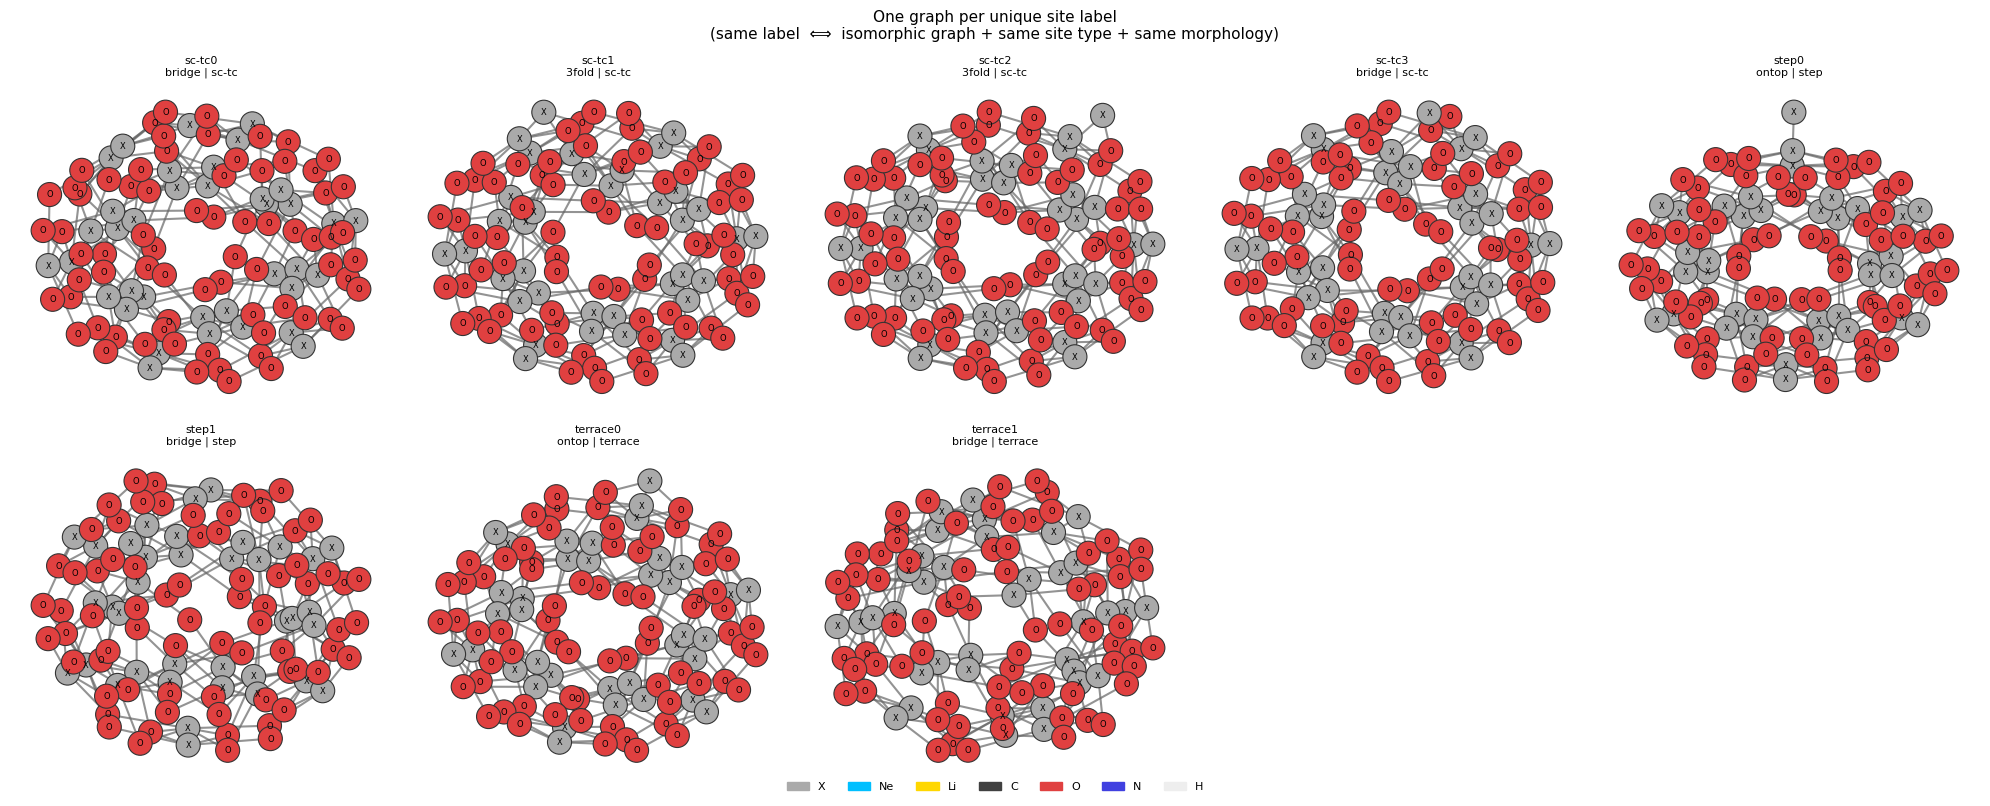

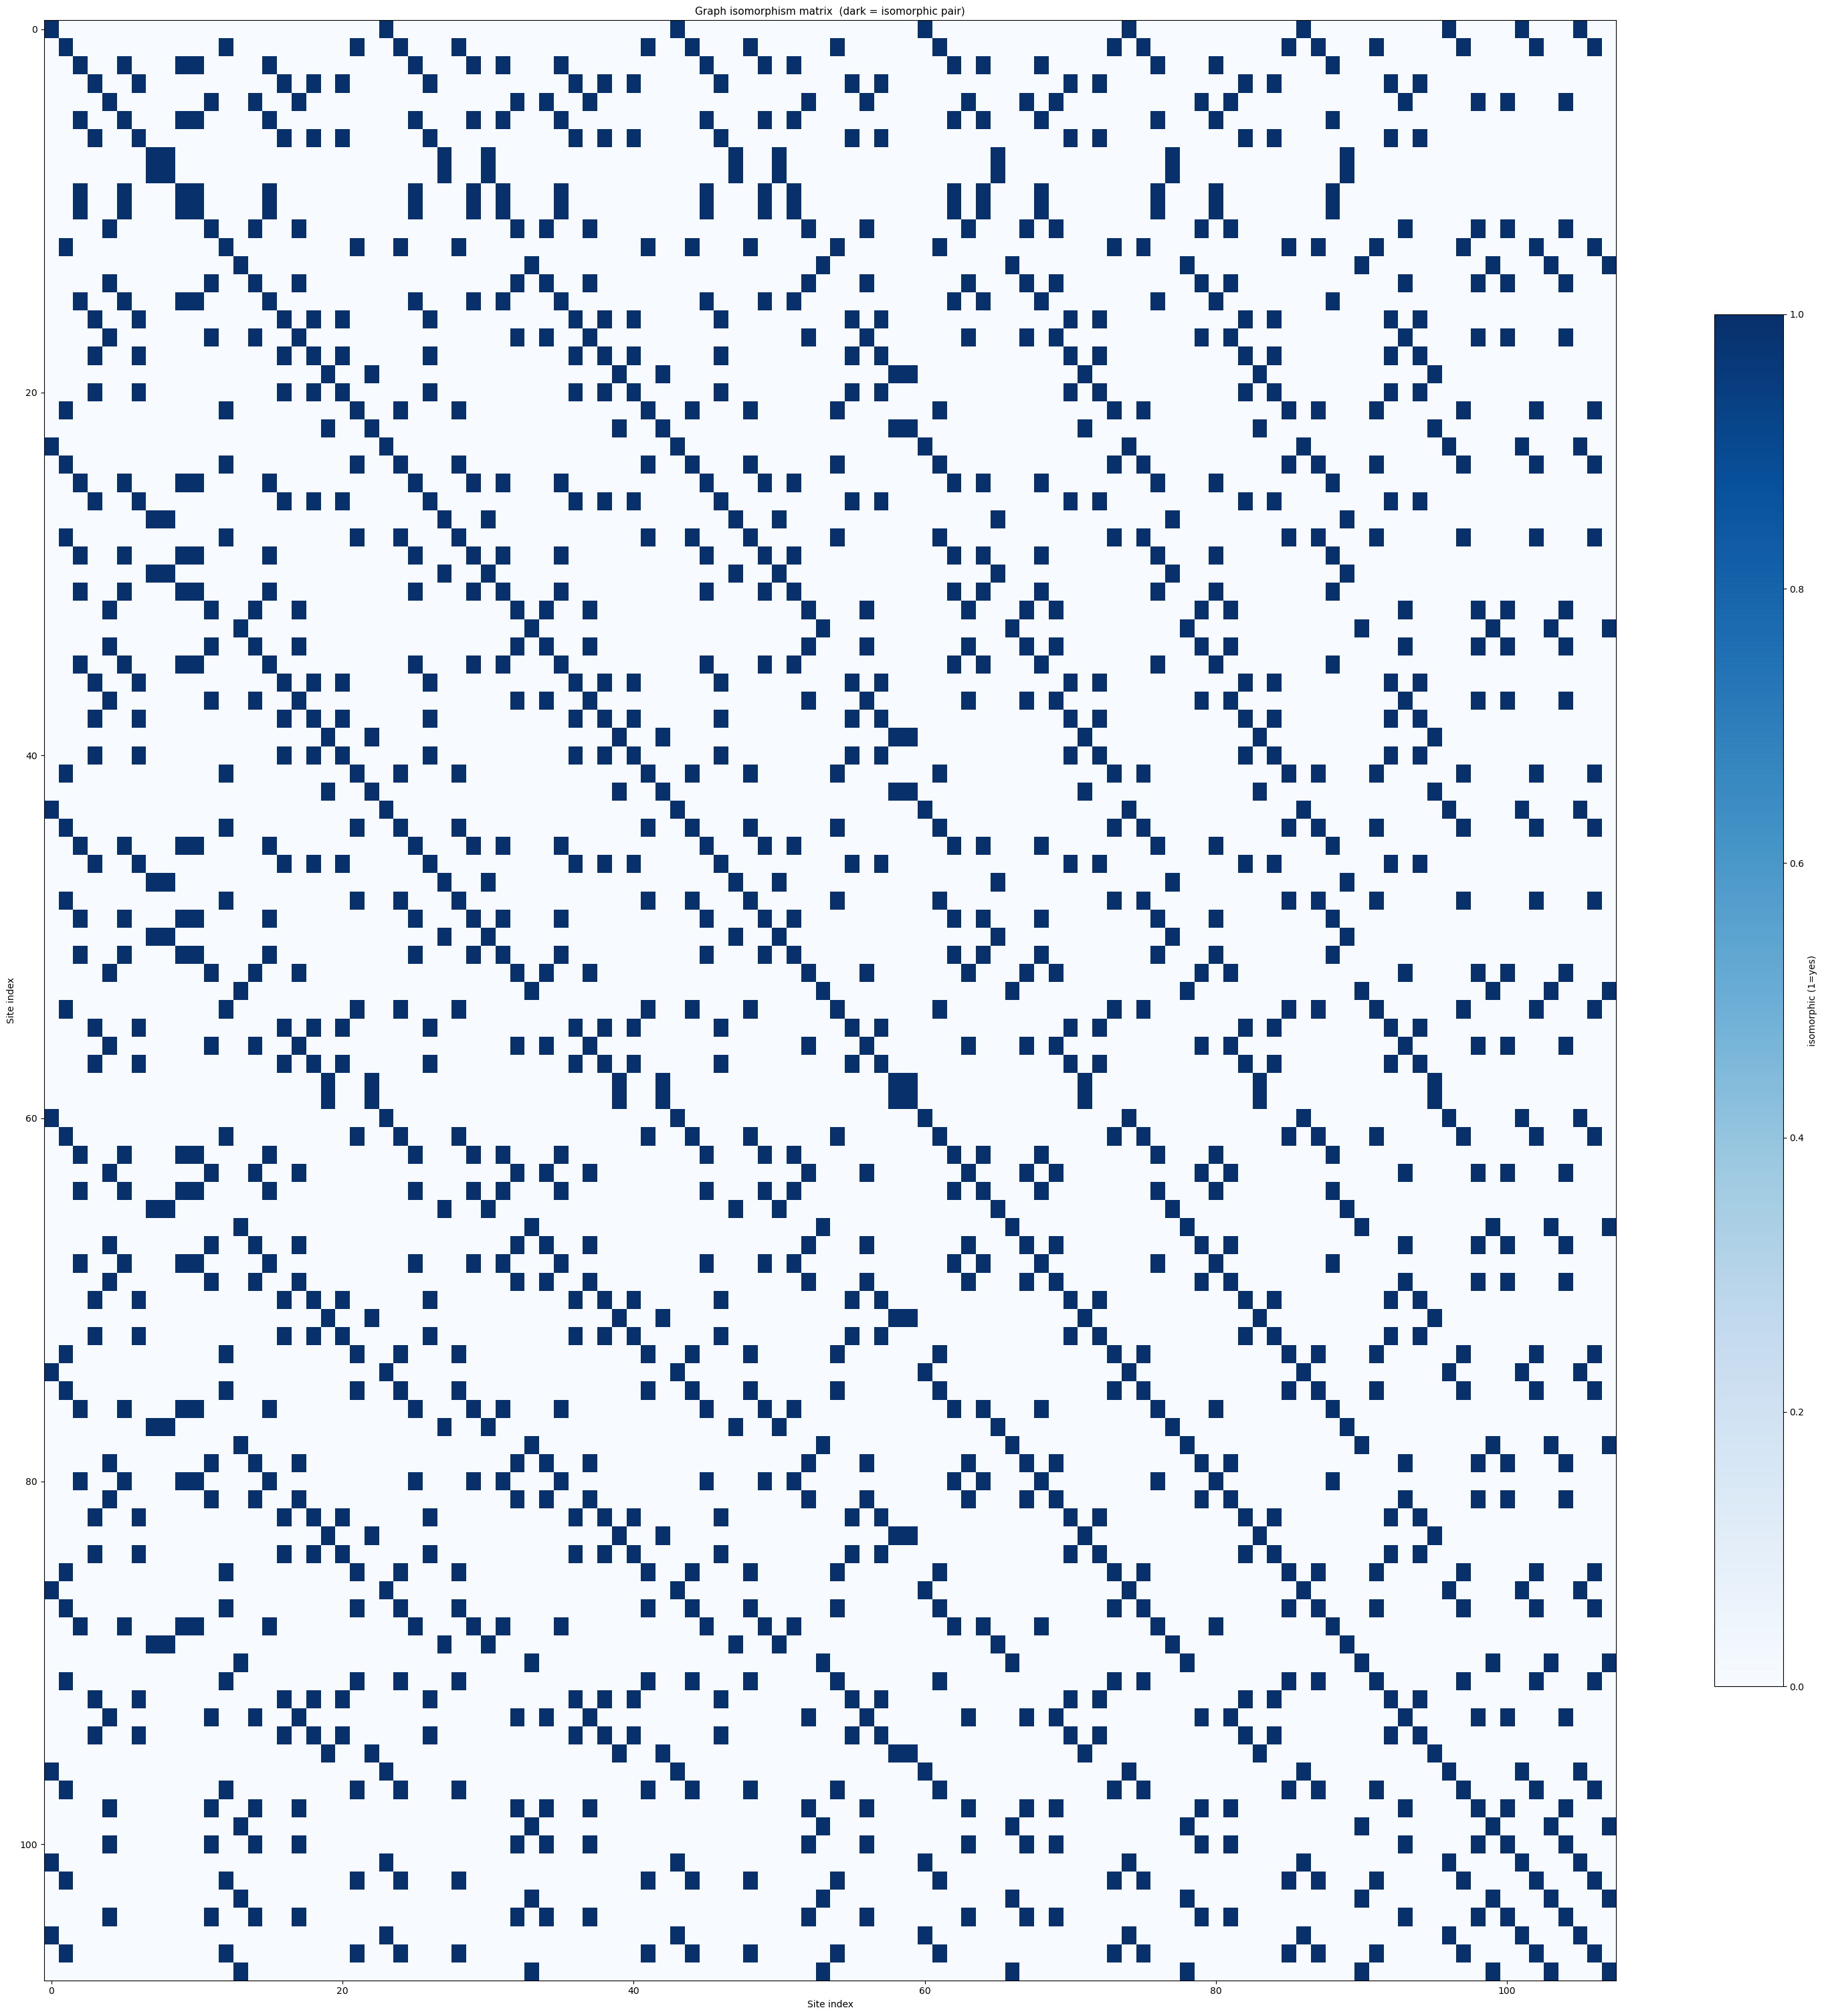

  Total ACAT sites (sites.json)    : 108
  Unique sites     (labeled_sites) : 8

  Each distinct label = one unique site environment.
  'Unique sites' = distinct labels (same thing).

  Label        Original site  Morphology
  ────────────────────────────────────────────
  sc-tc0       bridge         sc-tc
  sc-tc1       3fold          sc-tc
  sc-tc2       3fold          sc-tc
  sc-tc3       bridge         sc-tc
  step0        ontop          step
  step1        bridge         step
  terrace0     ontop          terrace
  terrace1     bridge         terrace


In [25]:
# Cell 4: visualize labeled sites
sa.visualize_labeled_sites(
    labeled_sites_json="labeled_sites.json",
    sites_json="sites.json",
)

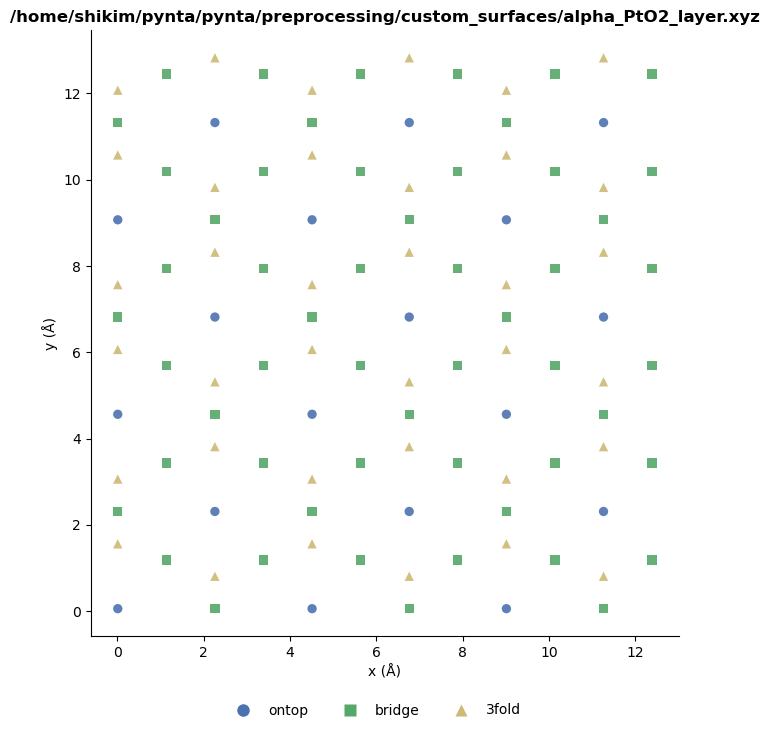

Saved: site_positions.png


In [26]:
with open("sites.json") as f:
    all_sites = json.load(f)

sa.scatter_sites(all_sites, xyz_path=xyz_path)

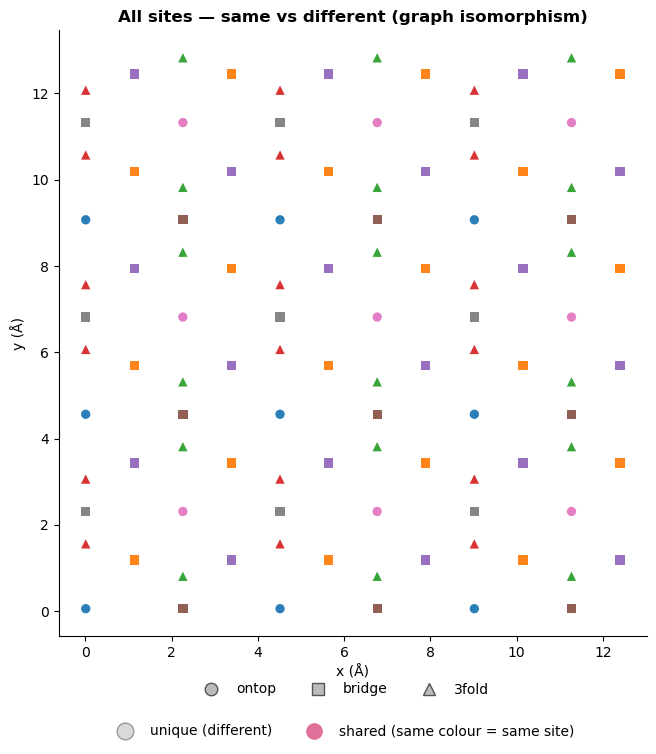

  ontop  : 18 sites -> 2 distinct; 2 group(s) are 'the same':
           terrace0 = terrace0 = terrace0 = terrace0 = terrace0 = terrace0 = terrace0 = terrace0 = terrace0
           step0 = step0 = step0 = step0 = step0 = step0 = step0 = step0 = step0
  bridge : 54 sites -> 4 distinct; 4 group(s) are 'the same':
           sc-tc0 = sc-tc0 = sc-tc0 = sc-tc0 = sc-tc0 = sc-tc0 = sc-tc0 = sc-tc0 = sc-tc0 = sc-tc0 = sc-tc0 = sc-tc0 = sc-tc0 = sc-tc0 = sc-tc0 = sc-tc0 = sc-tc0 = sc-tc0
           sc-tc3 = sc-tc3 = sc-tc3 = sc-tc3 = sc-tc3 = sc-tc3 = sc-tc3 = sc-tc3 = sc-tc3 = sc-tc3 = sc-tc3 = sc-tc3 = sc-tc3 = sc-tc3 = sc-tc3 = sc-tc3 = sc-tc3 = sc-tc3
           terrace1 = terrace1 = terrace1 = terrace1 = terrace1 = terrace1 = terrace1 = terrace1 = terrace1
           step1 = step1 = step1 = step1 = step1 = step1 = step1 = step1 = step1
  3fold  : 36 sites -> 2 distinct; 2 group(s) are 'the same':
           sc-tc1 = sc-tc1 = sc-tc1 = sc-tc1 = sc-tc1 = sc-tc1 = sc-tc1 = sc-tc1 = sc-tc1 = sc

{'ontop': {'n_sites': 18,
  'n_distinct': 2,
  'duplicate_groups': [['terrace0',
    'terrace0',
    'terrace0',
    'terrace0',
    'terrace0',
    'terrace0',
    'terrace0',
    'terrace0',
    'terrace0'],
   ['step0',
    'step0',
    'step0',
    'step0',
    'step0',
    'step0',
    'step0',
    'step0',
    'step0']]},
 'bridge': {'n_sites': 54,
  'n_distinct': 4,
  'duplicate_groups': [['sc-tc0',
    'sc-tc0',
    'sc-tc0',
    'sc-tc0',
    'sc-tc0',
    'sc-tc0',
    'sc-tc0',
    'sc-tc0',
    'sc-tc0',
    'sc-tc0',
    'sc-tc0',
    'sc-tc0',
    'sc-tc0',
    'sc-tc0',
    'sc-tc0',
    'sc-tc0',
    'sc-tc0',
    'sc-tc0'],
   ['sc-tc3',
    'sc-tc3',
    'sc-tc3',
    'sc-tc3',
    'sc-tc3',
    'sc-tc3',
    'sc-tc3',
    'sc-tc3',
    'sc-tc3',
    'sc-tc3',
    'sc-tc3',
    'sc-tc3',
    'sc-tc3',
    'sc-tc3',
    'sc-tc3',
    'sc-tc3',
    'sc-tc3',
    'sc-tc3'],
   ['terrace1',
    'terrace1',
    'terrace1',
    'terrace1',
    'terrace1',
    'terrace1',
  

In [27]:
# Cell 5: spatial same-vs-different map (graph isomorphism)
sa.plot_site_equivalence_xy(
    labeled_sites_json="labeled_sites.json",
    site_types=("ontop", "bridge", "3fold"),   # add "4fold"/"defect" if present
)